In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### data preprocessing


In [2]:
# Load the dataset sheet 'Online_Gaming_Behavior'
df = pd.read_excel('gaming_player_profile_datasets.xlsx', sheet_name='Online_Gaming_Behavior')
df.shape

(40034, 13)

In [3]:
# Display first few rows
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [4]:
# Check information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  str    
 3   Location                   40034 non-null  str    
 4   GameGenre                  40034 non-null  str    
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  str    
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  str    
dtypes: float64(1), int64(7), str(5)
memory usage: 4.0 MB


In [5]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000
Age,40034.0,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592
InGamePurchases,40034.0,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000
PlayerLevel,40034.0,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000
AchievementsUnlocked,40034.0,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000


### data wrangling


In [6]:
# Compute derived features: Play time per session and achievements per player level
df['PlayTimePerSession'] = df['PlayTimeHours'] / (df['SessionsPerWeek'] + 1e-5)
df['AchievementsPerLevel'] = df['AchievementsUnlocked'] / (df['PlayerLevel'] + 1e-5)
df[['PlayerID', 'PlayTimeHours', 'SessionsPerWeek', 'PlayTimePerSession', 'AchievementsPerLevel']].head()

,PlayerID,PlayTimeHours,SessionsPerWeek,PlayTimePerSession,AchievementsPerLevel
0,9000,16.271119,6,2.711849,0.316456
1,9001,5.525961,5,1.105190,0.909090
2,9002,8.223755,16,0.513984,1.171428
3,9003,5.265351,9,0.585038,0.824561
4,9004,15.531945,2,7.765933,0.389474


### data cleaning


In [7]:
# Check for missing values in all columns
df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
PlayTimePerSession           0
AchievementsPerLevel         0
dtype: int64

In [8]:
# Drop rows with missing values (if any) to ensure clean inputs
df = df.dropna()
df.shape

(40034, 15)

### handle duplicates


In [9]:
# Count duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [10]:
# Drop duplicate records
df = df.drop_duplicates()
df.shape

(40034, 15)

### outlier detection


In [11]:
# Use IQR method to check for outliers in numeric variables
for col in ['PlayTimeHours', 'AvgSessionDurationMinutes', 'Age']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f'Outliers in {col}: {outliers}')

Outliers in PlayTimeHours: 0
Outliers in AvgSessionDurationMinutes: 0
Outliers in Age: 0


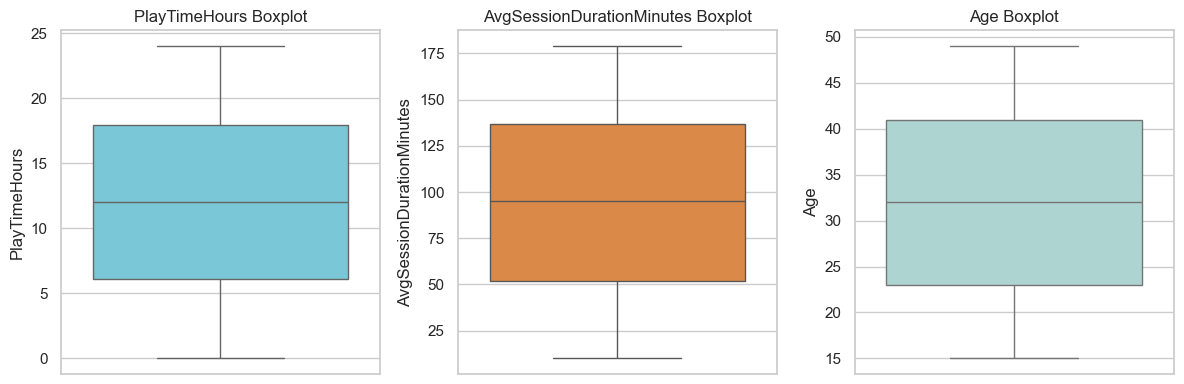

In [12]:
# Visualizing outliers using boxplots before capping
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['PlayTimeHours'], color='#69d2e7')
plt.title('PlayTimeHours Boxplot')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['AvgSessionDurationMinutes'], color='#f38630')
plt.title('AvgSessionDurationMinutes Boxplot')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Age'], color='#a7dbd8')
plt.title('Age Boxplot')
plt.tight_layout()
plt.show()

In [13]:
# Clip outliers to 1st and 99th percentiles (Winsorization)
for col in ['PlayTimeHours', 'AvgSessionDurationMinutes', 'Age']:
    lower_val = df[col].quantile(0.01)
    upper_val = df[col].quantile(0.99)
    df[col] = df[col].clip(lower_val, upper_val)

### data transformation


In [14]:
# Check skewness of key numeric columns
df[['PlayTimeHours', 'AvgSessionDurationMinutes', 'Age']].skew()

PlayTimeHours               -0.002244
AvgSessionDurationMinutes   -0.005600
Age                         -0.004466
dtype: float64

In [15]:
# Apply log transformation to highly skewed PlayTimeHours to normalize distributions
df['Log_PlayTimeHours'] = np.log1p(df['PlayTimeHours'])
df['Log_PlayTimeHours'].skew()

np.float64(-1.0468246968588122)

### scaling


In [16]:
# Standardize the numeric features for clustering using StandardScaler
scaler = StandardScaler()
numeric_cols = ['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 
                'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 
                'PlayTimePerSession', 'AchievementsPerLevel']
scaled_features = scaler.fit_transform(df[numeric_cols])
scaled_df = pd.DataFrame(scaled_features, columns=[f'{c}_scaled' for c in numeric_cols])
scaled_df.head()

,Age_scaled,PlayTimeHours_scaled,InGamePurchases_scaled,SessionsPerWeek_scaled,AvgSessionDurationMinutes_scaled,PlayerLevel_scaled,AchievementsUnlocked_scaled,PlayTimePerSession_scaled,AchievementsPerLevel_scaled
0,1.096023,0.614554,-0.501334,-0.602363,0.269597,1.026459,0.032814,-0.196276,-0.285599
1,-0.297969,-0.940382,-0.501334,-0.775865,1.004442,-1.352160,-1.006648,-0.196281,-0.109867
2,-0.994965,-0.549983,-0.501334,1.132666,0.963617,-0.512647,1.141573,-0.196283,-0.032077
3,0.299456,-0.978095,1.994676,-0.081854,-0.199887,0.256906,1.557358,-0.196283,-0.134932
4,0.100314,0.507588,-0.501334,-1.296374,0.739081,1.586134,0.864383,-0.196259,-0.263947


### encoding


In [17]:
# One-hot encode categorical features
categorical_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty']
encoded_df = pd.get_dummies(df[categorical_cols], drop_first=True, dtype=int)
encoded_df.head()

,Gender_Male,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,GameDifficulty_Hard,GameDifficulty_Medium
0,1,0,1,0,0,0,0,1,0,1
1,0,0,0,1,0,0,0,1,0,1
2,0,0,0,1,0,0,1,0,0,0
3,1,0,0,1,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1


In [18]:
# Combine scaled numeric features and encoded categorical features
clustering_features = pd.concat([scaled_df.reset_index(drop=True), 
                                 encoded_df.reset_index(drop=True)], axis=1)
clustering_features.head()

,Age_scaled,PlayTimeHours_scaled,InGamePurchases_scaled,SessionsPerWeek_scaled,AvgSessionDurationMinutes_scaled,PlayerLevel_scaled,AchievementsUnlocked_scaled,PlayTimePerSession_scaled,AchievementsPerLevel_scaled,Gender_Male,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,GameDifficulty_Hard,GameDifficulty_Medium
0,1.096023,0.614554,-0.501334,-0.602363,0.269597,1.026459,0.032814,-0.196276,-0.285599,1,0,1,0,0,0,0,1,0,1
1,-0.297969,-0.940382,-0.501334,-0.775865,1.004442,-1.352160,-1.006648,-0.196281,-0.109867,0,0,0,1,0,0,0,1,0,1
2,-0.994965,-0.549983,-0.501334,1.132666,0.963617,-0.512647,1.141573,-0.196283,-0.032077,0,0,0,1,0,0,1,0,0,0
3,0.299456,-0.978095,1.994676,-0.081854,-0.199887,0.256906,1.557358,-0.196283,-0.134932,1,0,0,1,0,0,0,0,0,0
4,0.100314,0.507588,-0.501334,-1.296374,0.739081,1.586134,0.864383,-0.196259,-0.263947,1,1,0,0,0,0,0,0,0,1


### eda


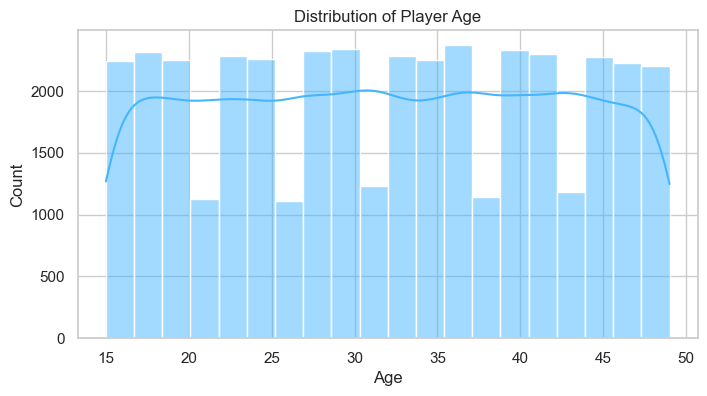

In [19]:
# Plot 1: Age Distribution Histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], kde=True, color='#45b6fe', bins=20)
plt.title('Distribution of Player Age', fontsize=12)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

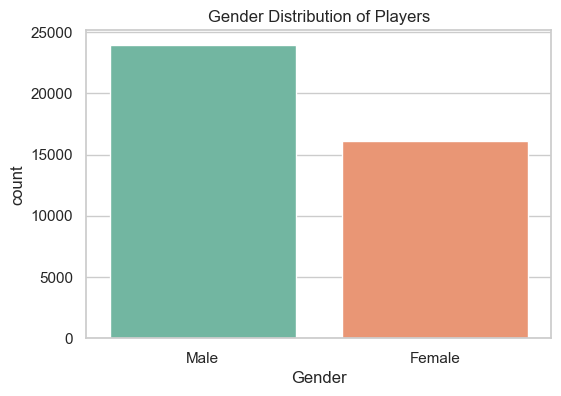

In [20]:
# Plot 2: Gender Distribution Countplot
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution of Players', fontsize=12)
plt.show()

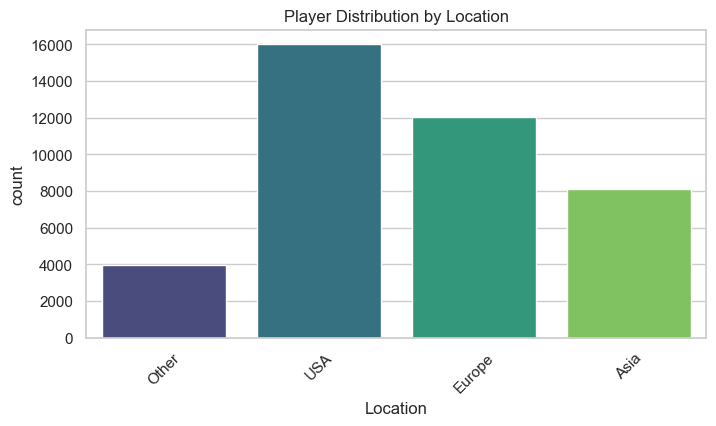

In [21]:
# Plot 3: Location Distribution Countplot
plt.figure(figsize=(8, 4))
sns.countplot(x='Location', data=df, palette='viridis')
plt.title('Player Distribution by Location', fontsize=12)
plt.xticks(rotation=45)
plt.show()

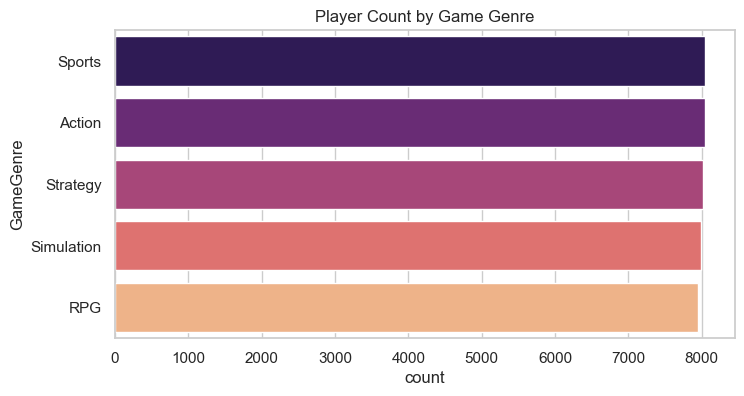

In [22]:
# Plot 4: Game Genre Distribution
plt.figure(figsize=(8, 4))
sns.countplot(y='GameGenre', data=df, order=df['GameGenre'].value_counts().index, palette='magma')
plt.title('Player Count by Game Genre', fontsize=12)
plt.show()

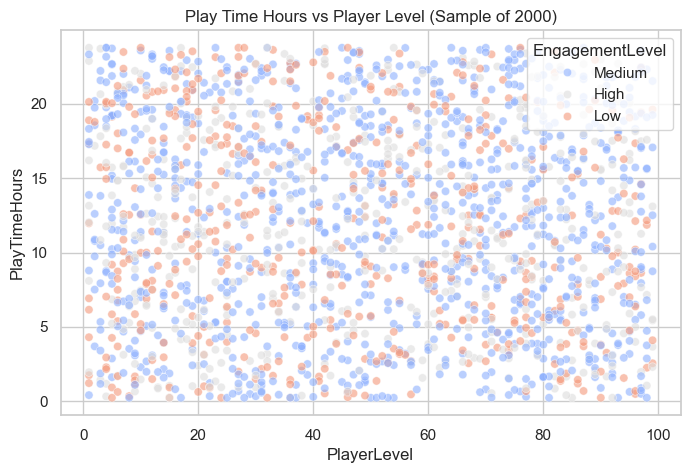

In [23]:
# Plot 5: Play Time Hours vs Player Level Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='PlayerLevel', y='PlayTimeHours', data=df.sample(2000, random_state=42), hue='EngagementLevel', alpha=0.6, palette='coolwarm')
plt.title('Play Time Hours vs Player Level (Sample of 2000)', fontsize=12)
plt.show()

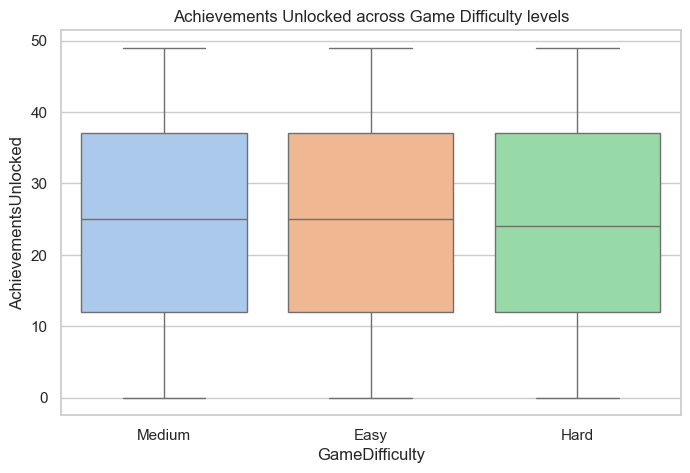

In [24]:
# Plot 6: Achievements Unlocked by Game Difficulty Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='GameDifficulty', y='AchievementsUnlocked', data=df, palette='pastel')
plt.title('Achievements Unlocked across Game Difficulty levels', fontsize=12)
plt.show()

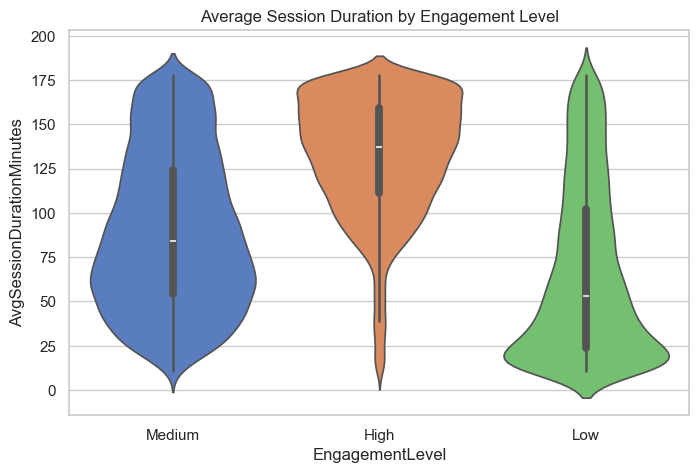

In [25]:
# Plot 7: Average Session Duration by Engagement Level Violin Plot
plt.figure(figsize=(8, 5))
sns.violinplot(x='EngagementLevel', y='AvgSessionDurationMinutes', data=df, palette='muted')
plt.title('Average Session Duration by Engagement Level', fontsize=12)
plt.show()

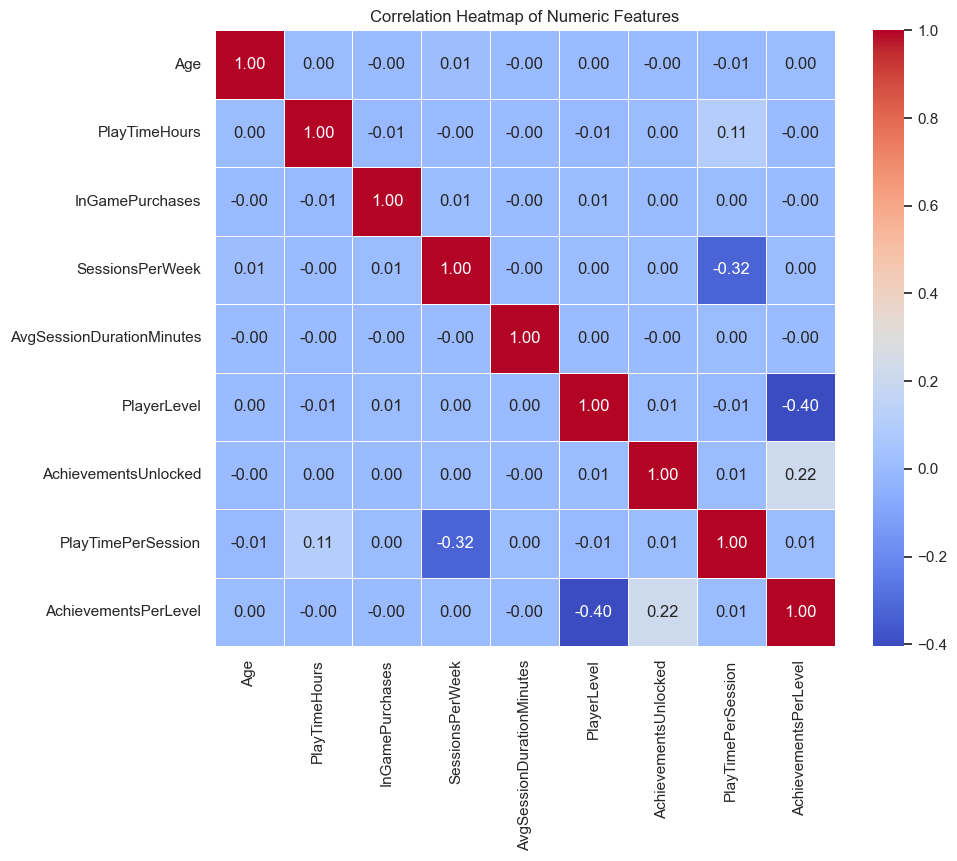

In [26]:
# Plot 8: Correlation Heatmap of Numeric Features
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=12)
plt.show()

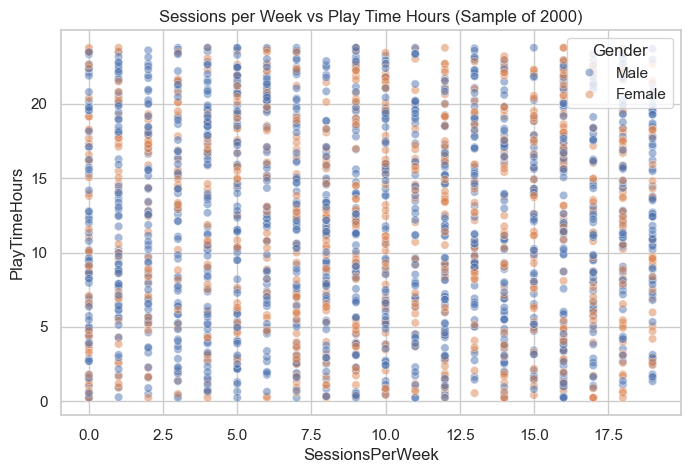

In [27]:
# Plot 9: Sessions per Week vs Play Time Hours Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='SessionsPerWeek', y='PlayTimeHours', data=df.sample(2000, random_state=42), hue='Gender', alpha=0.5)
plt.title('Sessions per Week vs Play Time Hours (Sample of 2000)', fontsize=12)
plt.show()

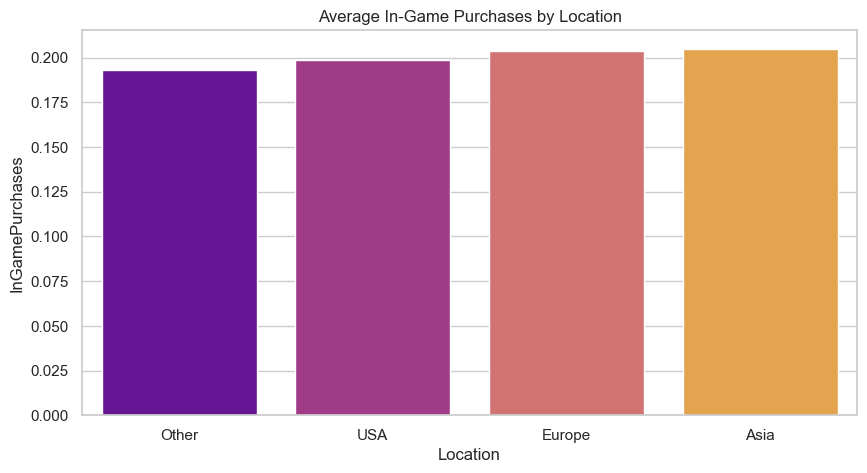

In [28]:
# Plot 10: In-Game Purchases Distribution by Location Bar Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Location', y='InGamePurchases', data=df, ci=None, palette='plasma')
plt.title('Average In-Game Purchases by Location', fontsize=12)
plt.show()

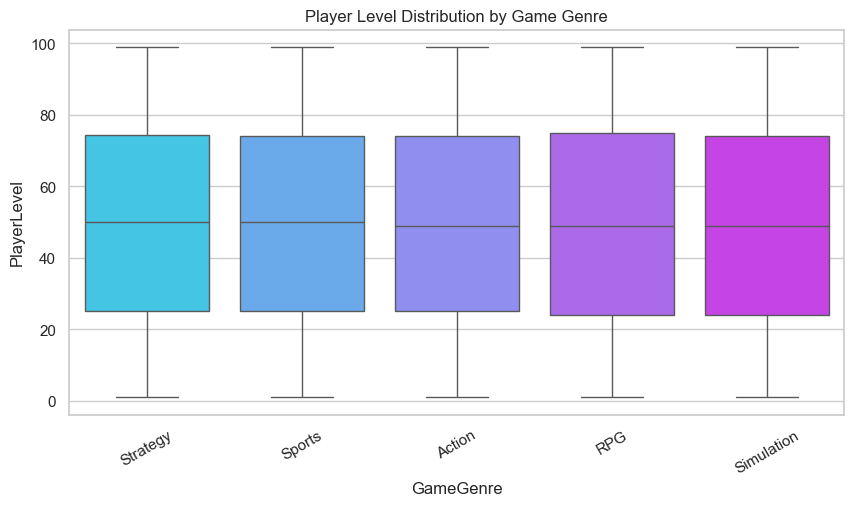

In [29]:
# Plot 11: Player Level Distribution by Game Genre Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x='GameGenre', y='PlayerLevel', data=df, palette='cool')
plt.title('Player Level Distribution by Game Genre', fontsize=12)
plt.xticks(rotation=30)
plt.show()

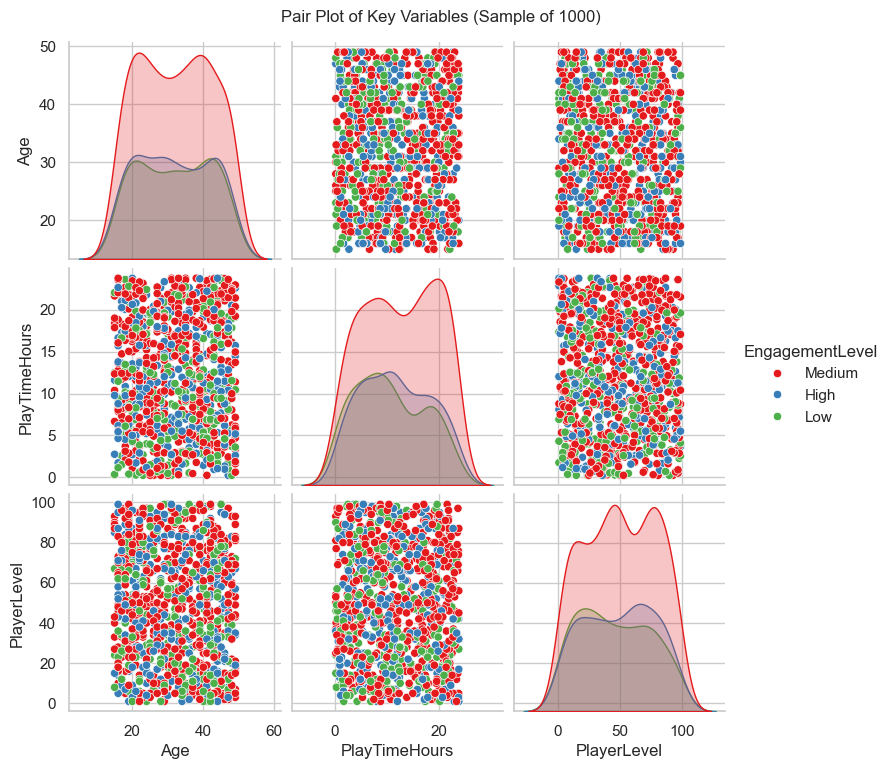

In [30]:
# Plot 12: Pair Plot of Key Variables
key_vars = ['Age', 'PlayTimeHours', 'PlayerLevel', 'EngagementLevel']
sns.pairplot(df[key_vars].sample(1000, random_state=42), hue='EngagementLevel', palette='Set1', diag_kind='kde')
plt.suptitle('Pair Plot of Key Variables (Sample of 1000)', y=1.02, fontsize=12)
plt.show()

### model deployment (DBSCAN)


In [31]:
# Initialize DBSCAN model with tuned parameters eps and min_samples
# eps=2.5, min_samples=20 (selected based on k-distance graph and grid search)
dbscan_model = DBSCAN(eps=2.5, min_samples=20)

### model fitting & cluster assignment


In [32]:
# Split clustering features into Train and Test datasets for consistent evaluation
X_train, X_test = train_test_split(clustering_features, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 32027
Testing set size: 8007


In [33]:
# Fit DBSCAN model on the training data
# Density-based clustering identifies clusters and isolates noise (-1)
train_clusters = dbscan_model.fit_predict(X_train)

In [34]:
# Fit DBSCAN on testing data to evaluate test cluster distribution and noise detection
test_clusters = dbscan_model.fit_predict(X_test)
print("Training set cluster distribution (Label -1 = Outliers/Noise):")
print(pd.Series(train_clusters).value_counts())
print("\nTesting set cluster distribution (Label -1 = Outliers/Noise):")
print(pd.Series(test_clusters).value_counts())

Training set cluster distribution (Label -1 = Outliers/Noise):
 0    25438
 1     6196
-1      353
 2       40
Name: count, dtype: int64

Testing set cluster distribution (Label -1 = Outliers/Noise):
 1    6150
 0    1534
-1     301
 2      22
Name: count, dtype: int64


### performance measure


In [35]:
# Calculate cluster counts and noise percentage on training set
n_train_clusters = len(set(train_clusters)) - (1 if -1 in train_clusters else 0)
n_train_noise = list(train_clusters).count(-1)
print(f'Estimated number of training clusters: {n_train_clusters}')
print(f'Estimated training noise points: {n_train_noise} ({n_train_noise/len(train_clusters):.2%})')

Estimated number of training clusters: 3
Estimated training noise points: 353 (1.10%)


### evaluation matrix


In [36]:
# Evaluate clustering quality using silhouette score, davies-bouldin, and calinski-harabasz score
# Filter out noise points (-1) for meaningful distance metric evaluation
test_sample = X_test.sample(5000, random_state=42)
sample_indices = test_sample.index
sample_clusters = test_clusters[X_test.index.get_indexer(sample_indices)]

non_noise_mask = sample_clusters != -1
if len(set(sample_clusters[non_noise_mask])) > 1:
    sil = silhouette_score(test_sample[non_noise_mask], sample_clusters[non_noise_mask])
    db = davies_bouldin_score(test_sample[non_noise_mask], sample_clusters[non_noise_mask])
    ch = calinski_harabasz_score(test_sample[non_noise_mask], sample_clusters[non_noise_mask])

    print(f'Silhouette Score (Non-Noise Test Sample): {sil:.4f}')
    print(f'Davies-Bouldin Index (Non-Noise Test Sample): {db:.4f}')
    print(f'Calinski-Harabasz Index (Non-Noise Test Sample): {ch:.4f}')
else:
    print("Insufficient non-noise clusters to compute silhouette scores.")

Silhouette Score (Non-Noise Test Sample): 0.1508
Davies-Bouldin Index (Non-Noise Test Sample): 1.7742
Calinski-Harabasz Index (Non-Noise Test Sample): 330.8628


### tuning method


In [37]:
# 1. K-Distance calculation for Epsilon (eps) selection
min_samples_val = 20
nn = NearestNeighbors(n_neighbors=min_samples_val)
nn.fit(X_train)
distances, _ = nn.kneighbors(X_train)
k_distances = np.sort(distances[:, -1])

# 2. Grid search over eps and min_samples on a sample of training data
tune_sample = X_train.sample(5000, random_state=42)
eps_range = [1.5, 2.0, 2.5, 3.0]
ms_range = [10, 20, 30]

tuning_results = []
for ms in ms_range:
    for eps in eps_range:
        db = DBSCAN(eps=eps, min_samples=ms)
        lbls = db.fit_predict(tune_sample)
        n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_n = list(lbls).count(-1)
        if n_c > 1 and (len(lbls) - n_n) > n_c:
            s_score = silhouette_score(tune_sample[lbls != -1], lbls[lbls != -1])
        else:
            s_score = np.nan
        tuning_results.append({'eps': eps, 'min_samples': ms, 'clusters': n_c, 'noise_ratio': f"{n_n/len(lbls):.1%}", 'silhouette': s_score})

tuning_df = pd.DataFrame(tuning_results)
print("DBSCAN Hyperparameter Grid Search Results:")
print(tuning_df)

DBSCAN Hyperparameter Grid Search Results:
    eps  min_samples  clusters noise_ratio  silhouette
0   1.5           10         5       97.5%    0.187263
1   2.0           10         4       17.0%    0.074716
2   2.5           10         2        2.4%    0.145395
3   3.0           10         1        0.8%         NaN
4   1.5           20         0      100.0%         NaN
5   2.0           20         3       29.3%    0.067449
6   2.5           20         3        4.7%    0.160043
7   3.0           20         1        1.3%         NaN
8   1.5           30         0      100.0%         NaN
9   2.0           30         1       40.3%         NaN
10  2.5           30         2        5.4%    0.159534
11  3.0           30         1        1.5%         NaN


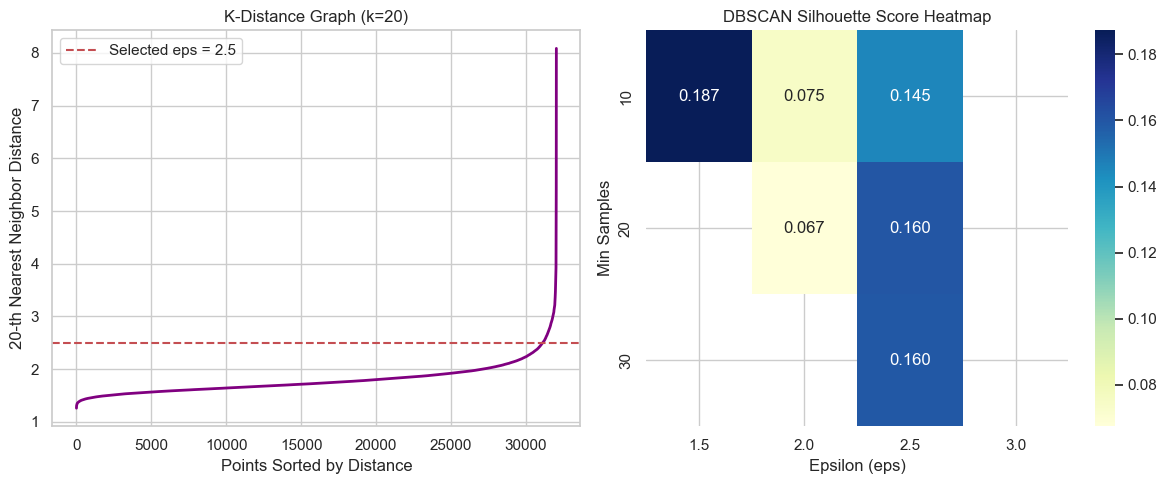

In [38]:
# Plot K-Distance curve (for eps detection) and Silhouette score heatmap across DBSCAN parameters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_distances, color='purple', linewidth=2)
plt.axhline(y=2.5, color='r', linestyle='--', label='Selected eps = 2.5')
plt.title(f'K-Distance Graph (k={min_samples_val})')
plt.xlabel('Points Sorted by Distance')
plt.ylabel(f'{min_samples_val}-th Nearest Neighbor Distance')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
pivot_df = tuning_df.pivot(index='min_samples', columns='eps', values='silhouette')
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('DBSCAN Silhouette Score Heatmap')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Min Samples')

plt.tight_layout()
plt.show()

### advanced features


In [39]:
# Reduce dimensionality to 2D using PCA for visual analysis of DBSCAN clusters
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X_test)
pca_df = pd.DataFrame(pca_features, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = [f'Cluster {c}' if c != -1 else 'Noise (-1)' for c in test_clusters]

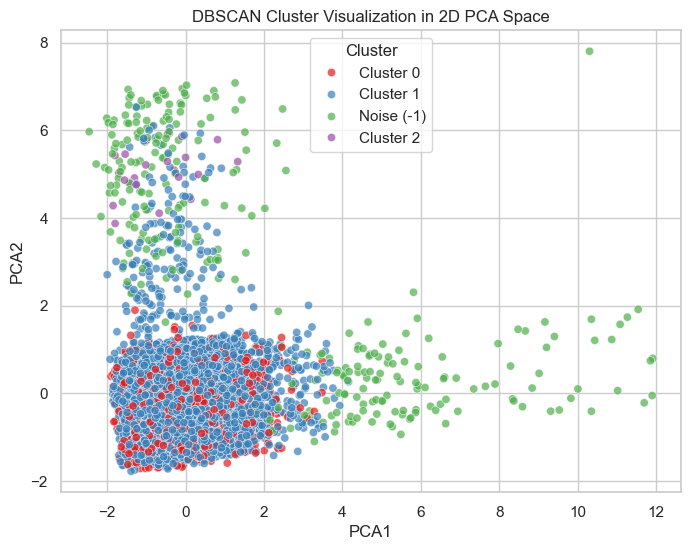

In [40]:
# Visualize the DBSCAN clusters in a 2D PCA projected space
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='Set1', alpha=0.7)
plt.title('DBSCAN Cluster Visualization in 2D PCA Space')
plt.show()

In [41]:
# Join the cluster assignments back to the original dataframe columns to profile each group
test_indices = X_test.index
test_df_original = df.loc[test_indices].copy()
test_df_original['Cluster'] = test_clusters

cluster_profile = test_df_original[numeric_cols + ['Cluster']].groupby('Cluster').mean()
cluster_profile.T

Cluster,-1,0,1,2
Age,32.066445,32.023468,32.187480,2.827273e+01
PlayTimeHours,14.473478,12.129661,11.912763,1.694561e+01
InGamePurchases,0.318937,1.000000,0.000000,0.000000e+00
SessionsPerWeek,4.710963,9.962842,9.577724,0.000000e+00
AvgSessionDurationMinutes,91.023256,93.014342,95.091220,1.302727e+02
PlayerLevel,29.162791,51.103651,49.758862,4.795455e+01
AchievementsUnlocked,29.328904,24.692308,24.169268,1.731818e+01
PlayTimePerSession,919720.818254,2225.745631,27668.271092,1.694561e+06
AchievementsPerLevel,10.853350,0.878575,0.931070,8.223540e-01


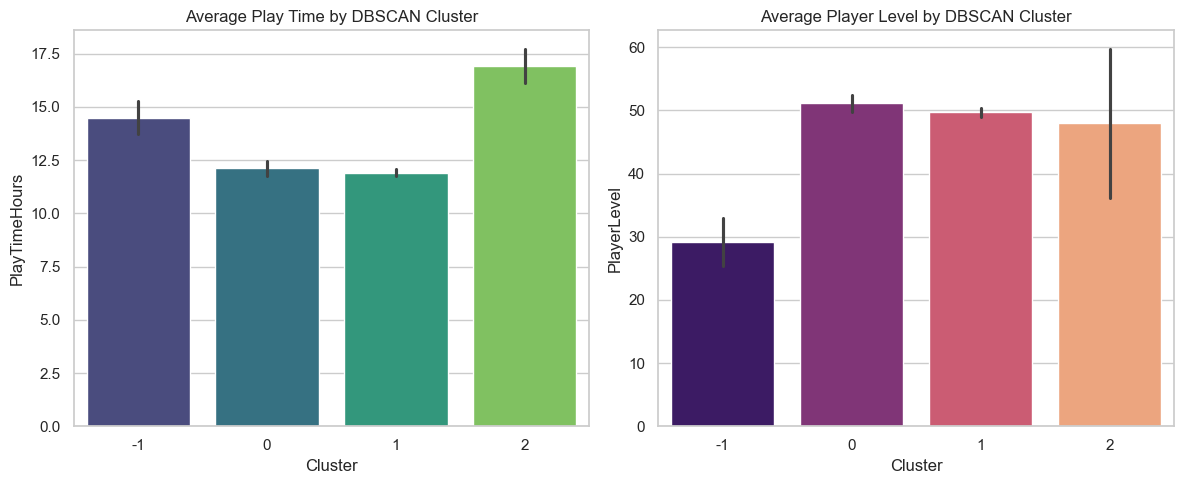

In [42]:
# Plot cluster differences on key metrics (PlayTimeHours and PlayerLevel)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Cluster', y='PlayTimeHours', data=test_df_original, palette='viridis')
plt.title('Average Play Time by DBSCAN Cluster')

plt.subplot(1, 2, 2)
sns.barplot(x='Cluster', y='PlayerLevel', data=test_df_original, palette='magma')
plt.title('Average Player Level by DBSCAN Cluster')
plt.tight_layout()
plt.show()

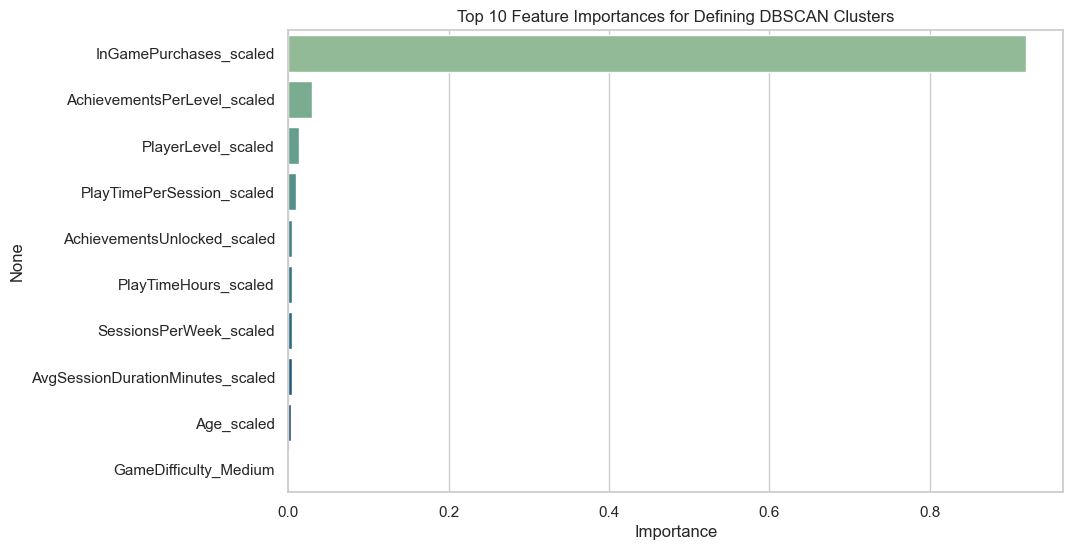

In [43]:
# Train a Random Forest classifier to determine which features define the DBSCAN clusters
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, train_clusters)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X_train.columns[indices][:10], palette='crest')
plt.title('Top 10 Feature Importances for Defining DBSCAN Clusters')
plt.xlabel('Importance')
plt.show()